# 12 — Korekta tekstu (literówki + diakrytyki)

Warianty: raw → +diakrytyki → +diakrytyki+literówki. Korektor budowany **wyłącznie z train** danego zbioru — bez słowników zewnętrznych, bez wycieku. Test nietknięty.

In [ ]:
import re, warnings
from collections import Counter
from pathlib import Path
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.multiclass import OneVsRestClassifier
from sklearn.metrics import f1_score
from thesis_lib import optimal_thresholds as opt_thr
warnings.filterwarnings("ignore"); sns.set_theme(style="whitegrid"); plt.rcParams["savefig.dpi"]=300

EMOTIONS=["radość","smutek","zaufanie","wstręt","strach","gniew","przeczuwanie","zdziwienie"]
RANDOM_STATE=42
PROCESSED_DIR=Path("../data/processed"); RESULTS_DIR=Path("../data/results"); FIGURES_DIR=Path("../figures")

DATASETS={"TW":("twitteremo","tekst"),"GO":("go_emotions","text_pl"),"CE":("clarin_emo","tekst")}
def load(name,col):
    out={}
    for sp in ["train","val","test"]:
        d=pd.read_csv(PROCESSED_DIR/f"{name}_{sp}.csv"); d[col]=d[col].fillna("")
        out[sp]={"text":d[col].tolist(),"y":d[EMOTIONS].values}
    return out
DATA={k:load(*v) for k,v in DATASETS.items()}
print({k:len(DATA[k]['train']['y']) for k in DATA})

In [2]:
# --- deDiakrytyzacja (PL) ---
PL_MAP=str.maketrans("ąćęłńóśźżĄĆĘŁŃÓŚŹŻ","acelnoszzACELNOSZZ")
def dediac(w): return w.translate(PL_MAP)
TOKEN_RE=re.compile(r"\w+", re.UNICODE)
def is_word(t): return t.isalpha() and len(t)>=3 and not t.startswith(("http","@","#"))

ALPHABET="aąbcćdeęfghijklłmnńoópqrsśtuvwxyzźż"
def edits1(w):
    sp=[(w[:i],w[i:]) for i in range(len(w)+1)]
    dele=[a+b[1:] for a,b in sp if b]
    repl=[a+c+b[1:] for a,b in sp if b for c in ALPHABET]
    ins=[a+c+b for a,b in sp for c in ALPHABET]
    return set(dele+repl+ins)

def build_corrector(train_texts):
    """Z train: częstości słów, mapa przywracania ogonków, słownik do literówek."""
    freq=Counter()
    for t in train_texts:
        for tok in TOKEN_RE.findall(str(t).lower()):
            if tok.isalpha(): freq[tok]+=1
    # przywracanie ogonków: dla klucza ascii -> najczęstsze słowo z ogonkami
    restore={}
    for w,c in freq.items():
        k=dediac(w)
        if k not in restore or c>freq[restore[k]]: restore[k]=w
    vocab={w for w,c in freq.items() if c>=2}
    return freq,restore,vocab

def correct_diacritics(text,restore):
    out=[];
    for tok in str(text).split():
        low=tok.lower()
        if is_word(low) and dediac(low)==low:           # token bez ogonków
            cand=restore.get(low)
            if cand and cand!=low: out.append(cand); continue
        out.append(tok)
    return " ".join(out)

def make_speller(freq,vocab,cache):
    def correct_token(low):
        if low in cache: return cache[low]
        res=low
        if is_word(low) and low not in vocab:
            cands=[w for w in edits1(low) if w in vocab]
            if cands: res=max(cands,key=lambda w:freq[w])
        cache[low]=res; return res
    return correct_token

def correct_spelling(text,speller):
    return " ".join(speller(tok.lower()) if is_word(tok.lower()) else tok for tok in str(text).split())

In [3]:
def variants_for(dom):
    """Zwraca 3 warianty (raw / +diac / +diac+spell) dla train/val/test + % zmian."""
    freq,restore,vocab=build_corrector(DATA[dom]["train"]["text"])
    cache={}; speller=make_speller(freq,vocab,cache)
    res={}
    changed_diac=changed_spell=total=0
    for sp in ["train","val","test"]:
        raw=DATA[dom][sp]["text"]
        diac=[correct_diacritics(t,restore) for t in raw]
        full=[correct_spelling(t,speller) for t in diac]
        res[sp]={"raw":raw,"diac":diac,"full":full}
        if sp=="test":
            for r,d,f in zip(raw,diac,full):
                rt=r.split()
                total+=len(rt)
                changed_diac+=sum(1 for a,b in zip(rt,d.split()) if a!=b)
                changed_spell+=sum(1 for a,b in zip(d.split(),f.split()) if a!=b)
    pct={"diac_%":round(100*changed_diac/max(total,1),2),"spell_%":round(100*changed_spell/max(total,1),2)}
    return res,pct

In [ ]:
def vec_for(kind):
    if kind=="char": return TfidfVectorizer(max_features=50_000,ngram_range=(3,5),analyzer="char_wb",min_df=3,sublinear_tf=True,lowercase=True)
    return TfidfVectorizer(max_features=50_000,ngram_range=(1,2),min_df=3,max_df=0.95,sublinear_tf=True,lowercase=True)

def evalrun(train_txt,val_txt,test_txt,ytr,yval,ytest,kind):
    vec=vec_for(kind)
    Xtr=vec.fit_transform(train_txt); Xva=vec.transform(val_txt); Xte=vec.transform(test_txt)
    clf=OneVsRestClassifier(LogisticRegression(max_iter=1000,C=1.0,class_weight="balanced",solver="liblinear",random_state=RANDOM_STATE))
    clf.fit(Xtr,ytr)
    thr=opt_thr(yval,clf.predict_proba(Xva))
    pred=(clf.predict_proba(Xte)>=thr).astype(int)
    return f1_score(ytest,pred,average="macro",zero_division=0)

In [5]:
rows=[]; pct_rows=[]
for dom in DATA:
    print(f"### {dom} — buduję warianty ...",flush=True)
    V,pct=variants_for(dom); pct_rows.append({"zbiór":dom,**pct})
    print(f"   zmienione tokeny (test): diakrytyki {pct['diac_%']}%, literówki {pct['spell_%']}%")
    ytr,yval,yte=DATA[dom]["train"]["y"],DATA[dom]["val"]["y"],DATA[dom]["test"]["y"]
    for kind in ["char","word"]:
        for var in ["raw","diac","full"]:
            f1=evalrun(V["train"][var],V["val"][var],V["test"][var],ytr,yval,yte,kind)
            rows.append({"zbiór":dom,"model":kind,"wariant":var,"f1_macro":round(f1,3)})
            print(f"   {kind:4s} × {var:4s}: F1-Macro={f1:.3f}")
res=pd.DataFrame(rows); res.to_csv(RESULTS_DIR/"correction_ablation.csv",index=False)
pctdf=pd.DataFrame(pct_rows); pctdf.to_csv(RESULTS_DIR/"correction_change_rate.csv",index=False)
print("\n% zmienionych tokenów (proxy szumu):"); display(pctdf)
display(res.pivot_table(index=["zbiór","model"],columns="wariant",values="f1_macro"))

### TW — buduję warianty ...


   zmienione tokeny (test): diakrytyki 0.89%, literówki 14.84%


   char × raw : F1-Macro=0.474


   char × diac: F1-Macro=0.460


   char × full: F1-Macro=0.462


...

   word × raw : F1-Macro=0.500


   word × diac: F1-Macro=0.501


   word × full: F1-Macro=0.507

% zmienionych tokenów (proxy szumu):


,zbiór,diac_%,spell_%
0,TW,0.89,14.84
1,GO,0.28,10.49
2,CE,1.54,12.65


wariant       diac   full    raw
zbiór model                     
CE    char   0.553  0.546  0.546
      word   0.501  0.507  0.500
GO    char   0.471  0.470  0.474
      word   0.438  0.439  0.437
TW    char   0.460  0.462  0.474
      word   0.409  0.419  0.410

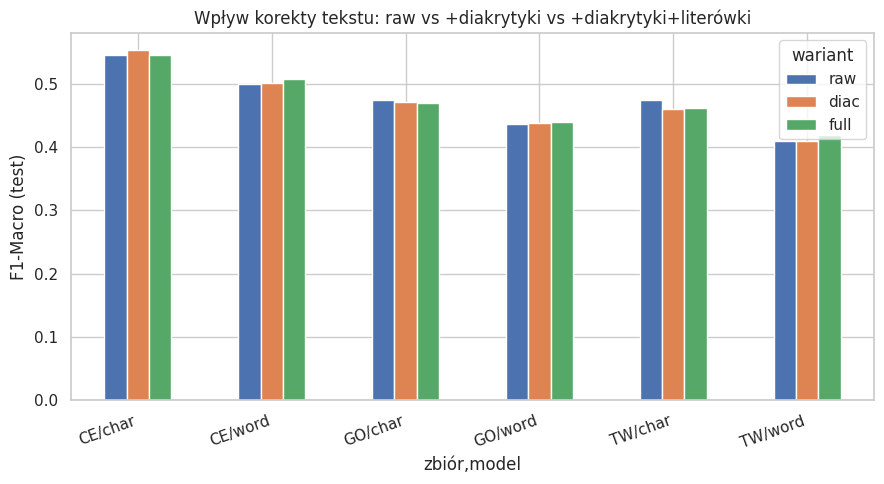

# Korekta tekstu — wnioski

- TW / char: raw 0.474 -> full 0.462 (-0.012)
- TW / word: raw 0.410 -> full 0.419 (+0.009)
- GO / char: raw 0.474 -> full 0.470 (-0.004)
- GO / word: raw 0.437 -> full 0.439 (+0.002)
- CE / char: raw 0.546 -> full 0.546 (+0.000)
- CE / word: raw 0.500 -> full 0.507 (+0.007)

- Najwięcej szumu (diakrytyki): CE (1.54% tokenów).


In [6]:
piv=res.pivot_table(index=["zbiór","model"],columns="wariant",values="f1_macro")[["raw","diac","full"]]
fig,ax=plt.subplots(figsize=(9,5))
piv.plot(kind="bar",ax=ax); ax.set_ylabel("F1-Macro (test)")
ax.set_title("Wpływ korekty tekstu: raw vs +diakrytyki vs +diakrytyki+literówki")
ax.set_xticklabels([f"{a}/{b}" for a,b in piv.index],rotation=20,ha="right"); ax.legend(title="wariant")
plt.tight_layout(); plt.savefig(FIGURES_DIR/"correction_ablation.pdf",bbox_inches="tight"); plt.show()
